## goal of this is to validate dV/dt (mass budget) for eq 1 in ASTE

In [1]:
# we already have this in the construction of the G terms. We can show this for a sample
# we can show that dV/dt of a given water mass (in the heat or salt budgets) is the same.

# the G budgets have already been shown - we can just use this for both

In [2]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [3]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [4]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

In [5]:
# --- Load edges (bounds) ---
T_edges = rdmds(layers_path + "layers2TH").reshape(-1)    # WAS boundsT (also WAS binsTH_edges)
S_edges = rdmds(layers_path + "layers1SLT").reshape(-1)   # WAS boundsS (also WAS binsSLT_edges)

nT = T_edges.size - 1                                     # WAS nT = binsTH_edges.shape[0]-1
nS = S_edges.size - 1                                     # WAS nS = binsSLT_edges.shape[0]-1

# --- Centers (midpoints between edges) ---
T_centers = 0.5 * (T_edges[:-1] + T_edges[1:])            # WAS binsTH_centers AND WAS binmidT (same quantity)
S_centers = 0.5 * (S_edges[:-1] + S_edges[1:])            # WAS binsSLT_centers AND WAS binmidS (same quantity; you had reshape(nT) bug)

# --- Widths per bin (edge-to-edge) ---
dT_edges = T_edges[1:] - T_edges[:-1]                     # WAS binwidthT
dS_edges = S_edges[1:] - S_edges[:-1]                     # WAS binwidthS

# Optional: "centered widths" (midpoints between adjacent widths)
dT_centers = 0.5 * (dT_edges[:-1] + dT_edges[1:])         # WAS binwidthT1
dS_centers = 0.5 * (dS_edges[:-1] + dS_edges[1:])         # WAS binwidthS1

# --- Inner edges (NOT centers) ---
T_inner_edges = T_edges[1:-1]                             # WAS binmidTp  (you called these "midpoints" but they are interior BOUNDS)
S_inner_edges = S_edges[1:-1]                             # WAS binmidSp  (same: interior BOUNDS, not centers)

# --- 2D grids (meshgrids) ---
T_edges_2d, S_edges_2d = np.meshgrid(T_edges, S_edges)                 # WAS Tbin, Sbin
T_centers_2d, S_centers_2d = np.meshgrid(T_centers, S_centers)         # WAS Tbincent, Sbincent
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)  # WAS Tbin2, Sbin2

# If you need 3D widths broadcasted as (nS, nT, 1)
dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)            # WAS dT, dS from meshgrid(binwidthT, binwidthS)
dT_3d = dT_3d.reshape(nS, nT, 1)                           # WAS dT = dT.reshape(112,112,1) (but use nS,nT not hardcode)
dS_3d = dS_3d.reshape(nS, nT, 1)                           # WAS dS = dS.reshape(112,112,1)

In [6]:
# important notes
# T_edges --< boundsT
# T_centers --< binsTH_centers, binmidT
# T_inner_edges --< boundsT.flatten()[1:-1]

## Load a single point here

In [7]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [8]:
# create the iwet for a specific, singular column with two cells.
iy,ix = 150,19

In [9]:
# create iwet from a mask at these points
mymsk = np.full((ny,nx),np.nan)
mymsk[iy,ix] = 1
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [10]:
# iwet_mine

## Load the RHS terms (from G_S and G_T total tend).

In [11]:
dt = 1800 # single time step

In [12]:
# I think this will just be total T tend + total S tend
file_name = 'budg2d_snap_set1'
meta_budg2d_snap_set1 = parsemeta(dirbudg + file_name + "." + tsstr[0] + ".meta")

# try to read this with rec
fldlist = np.array(meta_budg2d_snap_set1['fldList'])
varnames = np.array(['ETAN','PHIBOT','SIheff','SIhsnow'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])

ETAN = np.full((len(tsstr),ny,nx),np.nan)
PHIBOT = np.full((len(tsstr),ny,nx),np.nan)
SIheff = np.full((len(tsstr),ny,nx),np.nan)
SIhsnow = np.full((len(tsstr),ny,nx),np.nan)

for i in range(len(tsstr)):
    thisETAN,its,meta = rdmds(os.path.join(dirbudg, file_name),int(tsstr[i]),returnmeta=True,rec=recs[0])
    thisETAN = thisETAN.reshape(ny,nx)
    ETAN[i] = thisETAN

    thisPHIBOT,its,meta = rdmds(os.path.join(dirbudg, file_name),int(tsstr[i]),returnmeta=True,rec=recs[1])
    thisPHIBOT = thisPHIBOT.reshape(ny,nx)
    PHIBOT[i] = thisPHIBOT

    thisSIheff,its,meta = rdmds(os.path.join(dirbudg, file_name),int(tsstr[i]),returnmeta=True,rec=recs[2])
    thisSIheff = thisSIheff.reshape(ny,nx)
    SIheff[i] = thisSIheff

    thisSIhsnow,its,meta = rdmds(os.path.join(dirbudg, file_name),int(tsstr[i]),returnmeta=True,rec=recs[3])
    thisSIhsnow = thisSIhsnow.reshape(ny,nx)
    SIhsnow[i] = thisSIhsnow

ETAN =  (ETAN[1, :, :] - ETAN[0, :, :]) / dt    # m/s
PHIBOT = (PHIBOT[1, :, :] - PHIBOT[0, :, :]) / dt
SIheff =  (SIheff[1, :, :] - SIheff[0, :, :]) / dt
SIhsnow = (SIhsnow[1, :, :] - SIhsnow[0, :, :]) / dt

In [13]:
# get the volume budget for this equation

# 3D, with rStar:
# mk3D_mod function should be called here but I might be doing it wrong
tmptend = np.zeros((nz, ny, nx))
if myparms['useNLFS'] < 2 or myparms['rStar'] == 0:        # not this time
    tmptend[0,:, :] = ETAN * myparms['rhoconst'] * RAC     # m/s * kg/m^3 * m  = kg/s
    if myparms['useRFWF'] == 0:
        tmptend[0, :, :] = np.zeros((ny, nx))
else:
    if myparms['useRFWF'] != 0:                                 # we are using this  # check if tmp1 is the same as drf3d!!
        tmp1 = mk3D_mod(mygrid['DRF'],hfC) * hfC           # m
        tmp2 = tmp1/mk3D_mod(DD,tmp1)                      # m/m
        print("eta")
    else:
        tmp2 = drf3d / mk3D_mod(DD, tmp1)
        
    tmptend = tmp2 * np.tile(ETAN[np.newaxis,:,:],(nz,1,1)) * RAC3  # m/m * m/s * m^2 = m^3/s

eta


In [34]:
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

# example: first 2 vertical levels at one (iy, ix)
Tvals = THETA[:2, iy, ix].ravel()
Svals = SALT[:2, iy, ix].ravel()

print("Tvals:", Tvals)
print("Svals:", Svals)

def nearest_center_bin(centers, x):
    centers = np.asarray(centers)
    x = np.asarray(x)

    j = np.searchsorted(centers, x, side="left")
    j = np.clip(j, 1, centers.size - 1)

    left, right = centers[j-1], centers[j]
    j = j - (np.abs(x - left) <= np.abs(x - right))  # nearest center index in [0..n-1]

    return j - 1  # shift to your convention

Ti_bin = nearest_center_bin(T_centers, Tvals)
Si_bin = nearest_center_bin(S_centers, Svals)

print("T nearest bins:", Ti_bin, "T centers:", T_centers[Ti_bin + 1])
print("S nearest bins:", Si_bin, "S centers:", S_centers[Si_bin + 1])

Tvals: [-1.82381129 -1.82459402]
Svals: [33.32093048 33.33365631]
T nearest bins: [1 1] T centers: [-1.80000001 -1.80000001]
S nearest bins: [84 84] S centers: [33.375 33.375]


In [15]:
DRF3d = np.tile(mygrid['DRF'][:,np.newaxis,np.newaxis],(1,ny,nx))

In [16]:
# do the same print statement and print at the snapshots
# budg3d_snap_set2.0000000004.meta
# I think this will just be total T tend + total S tend
file_name = 'budg3d_snap_set2'
meta_budg3d_snap_set2 = parsemeta(dirbudg + file_name + "." + tsstr[0] + ".meta")

# try to read this with rec
fldlist = np.array(meta_budg3d_snap_set2['fldList'])
varnames = np.array(['THETADR','SALTDR'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])

THETADR = np.full((len(tsstr),nz,ny,nx),np.nan)
SALTDR = np.full((len(tsstr),nz,ny,nx),np.nan)

for i in range(len(tsstr)):
    thisTHETADR,its,meta = rdmds(os.path.join(dirbudg, file_name),int(tsstr[i]),returnmeta=True,rec=recs[0])
    thisTHETADR = thisTHETADR.reshape(nz,ny,nx)
    THETADR[i] = thisTHETADR

    thisSALTDR,its,meta = rdmds(os.path.join(dirbudg, file_name),int(tsstr[i]),returnmeta=True,rec=recs[1])
    thisSALTDR = thisSALTDR.reshape(nz,ny,nx)
    SALTDR[i] = thisSALTDR

dTHETADRdt =  (THETADR[1, :,:, :] - THETADR[0, :,:, :]) / dt * mk3D_mod(RAC,THETADR[1])
dSALTDRdt = (SALTDR[1, :,:, :] - SALTDR[0, :,:, :]) / dt * mk3D_mod(RAC,SALTDR[1])

In [36]:
for i in range(2):
    myT = (THETADR[i] / DRF3d)[:2,iy,ix]
    myS = (SALTDR[i] / DRF3d)[:2,iy,ix]
    
    # get the T and S bins for the two snaps
    Ti_bin2 = nearest_center_bin(T_centers, myT)
    Si_bin2 = nearest_center_bin(S_centers, myS)
    
    print("T nearest bins:", Ti_bin2, "T centers:", T_centers[Ti_bin + 1])
    print("S nearest bins:", Si_bin2, "S centers:", S_centers[Si_bin + 1])
    print()

T nearest bins: [1 1] T centers: [-1.80000001 -1.80000001]
S nearest bins: [75 75] S centers: [33.375 33.375]

T nearest bins: [1 1] T centers: [-1.80000001 -1.80000001]
S nearest bins: [75 75] S centers: [33.375 33.375]



In [37]:
# anyways I think the point of this is that it is the same bin at both timesteps

In [38]:
# we have tmptend here
tmptend[:2,iy,ix]   # m^3/s into these T bins

array([236.95417145, 236.95417145])

## Load the G_S and G_T (including the gates) for this timestep

In [39]:
# load the G_S and G_T for offline for the same column in the package
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

# load these terms 
dt = 1800

MsumT,dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=False,debug=True)
MsumS,dF_Snew = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=False,debug=True)
# these have advh, advr, dfh, dfr, surf, kpp, tend and have not been normalized

In [40]:
# /home/atnguyen/matlab_mnt_nansen/HelenPillar_layers/verify_J_G_M.m
# for updated files

In [41]:
# we validate the volume difference by printing LHS/RHS for dF_Tnew and dF_Snew

In [42]:
labels = np.array(["ADVh","ADVr","DFh","DFr","kpp","surf","tend"])
for i in range(6):
    print(labels[i],np.nansum(dF_Tnew[i]/dT_centers),"m^3/s")

print()
print(np.nansum(dF_Tnew[:-1]/dT_centers),"m^3/s")
print(np.nansum(dF_Tnew[-1]/dT_centers),"m^3/s")

ADVh -2987.79619029238 m^3/s
ADVr 0.0 m^3/s
DFh 25.196232375176585 m^3/s
DFr 0.0 m^3/s
kpp 112.13955156912986 m^3/s
surf 0.0 m^3/s

-2850.4604063480733 m^3/s
-2850.460406369026 m^3/s


In [43]:
# do the same for the salt budget

labels = np.array(["ADVh","ADVr","DFh","DFr","kpp","surf","tend"])
for i in range(6):
    print(labels[i],np.nansum(dF_Snew[i]/dS_centers),"m^3/s")

print()
print(np.nansum(dF_Snew[:-1]/dS_centers),"m^3/s")
print(np.nansum(dF_Snew[-1]/dS_centers),"m^3/s")

ADVh 83310.54469007917 m^3/s
ADVr 0.0 m^3/s
DFh 1.2323752977830438 m^3/s
DFr 0.0 m^3/s
kpp -28784.762806834522 m^3/s
surf 0.0 m^3/s

54527.01425854243 m^3/s
54527.01425978761 m^3/s


In [44]:
# get the Msum from ADVx and ADVy of the terms
file_name = "budg3d_hflux_set2"
meta_budg3d_hflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_hflux_set2["fldList"])
varnames = np.array(["ADVx_TH","ADVy_TH","ADVx_SLT","ADVy_SLT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVx_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
ADVy_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
ADVx_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
ADVy_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[3])

ADVx_TH = ADVx_TH.reshape((nz,ny,nx))
ADVy_TH = ADVy_TH.reshape((nz,ny,nx))
ADVx_SLT = ADVx_SLT.reshape((nz,ny,nx))
ADVy_SLT = ADVy_SLT.reshape((nz,ny,nx))

In [45]:
# get the values at the gates from the iy and ix
M_NT = -ADVy_TH[:,iy+1,ix]
M_NS = -ADVy_SLT[:,iy+1,ix]
M_WT = ADVx_TH[:,iy,ix]
M_WS = ADVx_SLT[:,iy,ix]

In [46]:
Ti_bin
Si_bin

array([84, 84])

In [47]:
print(np.nansum(M_NT + M_WT) / dT_centers[Ti_bin[0]])

-2987.79619029238


In [48]:
print(np.nansum(M_NS + M_WS) / dS_centers[Si_bin[0]])

83310.54469007917


In [49]:
# these are the same as the contributions from before and therefore the volume budget is closed.
# now to try and look at An's code.

## Also plot these against the layers output for G to validate this

In [50]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [51]:
ffac=1e-6
G_T=np.array([])
metaT=parsemeta(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[1] + ".meta")
nFldsT = metaT["fldList"]
print(len(nFldsT))
setTtend=nFldsT.copy()
fldsIwant = np.array(['LaTh2TH','LaTz2TH'])

# check for the correct diagnostics
metaT['fldList']   # 13, 14, 15, 16, 19, 22
b = metaT['fldList']
ifldT = np.array([1,2])    # surf, hDiff, vDiff, hADV, vADV, total tend
# print(np.array(b)[ifldT])  # for G_T

# remake the following to look for the existing terms and see if we can recreate
# ['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
ifldT = np.array([0,1,2,7,8,11])
print(np.array(b)[ifldT])  # for G_T


# we will just do the exact same thing for all the terms
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[1] + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setStend=nFldsS.copy()

# check for the correct diagnostics
metaS['fldList']   # 13, 14, 15, 16, 19, 22
b = metaS['fldList']
# ['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']
ifldS = np.array([12,13,14,19,20,23])

# print(b[12,13,14,19,20,23])
print(np.array(b)[ifldS])  # for G_S

24
['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


In [52]:
# create iwet from a mask at these points
mymsk = np.full((ny,nx),np.nan)
mymsk[iy,ix] = 1
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing
iwet_mine

array([13519])

In [53]:
# load G_T and G_S for this specific point online
# we did not mask this or the other one which is why they are the same
# try to make sure we maskt this here.

name = "BarentsS"
G_T = {}
G_T[name] = {}
ts = tsstr[1]
    
# now loop through
G_T[name][ts] = {}
for i in range(len(ifldT)-1, -1, -1):
    tmp = read_float64_skip(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[-1] + ".data", nx*ny*(nT-1),ifldT[i])
    tmp = np.reshape(tmp,(nT-1,nx*ny))
    tmp = tmp * (rac2dtile * hf2dtile) #* ffac

    if i == ifldT.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residT = tmp
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residT = residT-tmp
    
    # just do the Barents Sea for this one
    a = np.nansum(tmp[:,iwet_mine],axis=1)
    G_T[name][ts][setTtend[ifldT[i]]] = a

# residT was wrong here so we can just ignore

# let's try to verify with G_T first and then start with G_S
# make the G_T term
# we did not mask this or the other one which is why they are the same
# try to make sure we maskt this here.
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + "0000000003" + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setTtend=nFldsT.copy()
# check for the correct diagnostics
metaS['fldList']   # 13, 14, 15, 16, 19, 22
b = metaS['fldList']
# ['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']
ifldS = np.array([12,13,14,19,20,23])

# print(b[12,13,14,19,20,23])
print(np.array(b)[ifldS])  # for G_S

# make the G_T term
G_S = {}
G_S["BarentsS"] = {}
    
# now loop through
G_S["BarentsS"][ts] = {}
for i in range(len(ifldS)-1, -1, -1):
    tmp = read_float64_skip(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[-1] + ".data", nx*ny*(nS-1),ifldS[i])
    tmp = np.reshape(tmp,(nS-1,nx*ny))

    # here we will want to multiply by the mask for the Barents Sea
    tmp = tmp * mymsk_1dtile * (rac2dtile * hf2dtile) #* ffac

    if i == ifldS.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residS = tmp
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residS = residT-tmp
    
    # just do the Barents Sea for this one
    a = np.nansum(tmp[:,iwet_mine],axis=1)
    G_S["BarentsS"][ts][setTtend[ifldS[i]]] = a


24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


In [54]:
print(G_T['BarentsS'][ts].keys())
print(G_S['BarentsS'][ts].keys())

# the order of these is tend, advr, advh, dfr, dfh, surf

new_order = ['LTha2TH', 'LTza2TH', 'LaTh2TH', 'LaTz2TH', 'LaTs2TH', 'LTto2TH']
dT = G_T['BarentsS'][ts]
G_T['BarentsS'][ts] = {k: dT[k] for k in new_order}


new_order = ['LTha1SLT', 'LTza1SLT', 'LaTh1SLT', 'LaTz1SLT', 'LaTs1SLT', 'LTto1SLT']
dS = G_S['BarentsS'][ts]
G_S['BarentsS'][ts] = {k: dS[k] for k in new_order}

dict_keys(['LTto2TH', 'LTza2TH', 'LTha2TH', 'LaTz2TH', 'LaTh2TH', 'LaTs2TH'])
dict_keys(['LTto1SLT', 'LTza1SLT', 'LTha1SLT', 'LaTz1SLT', 'LaTh1SLT', 'LaTs1SLT'])


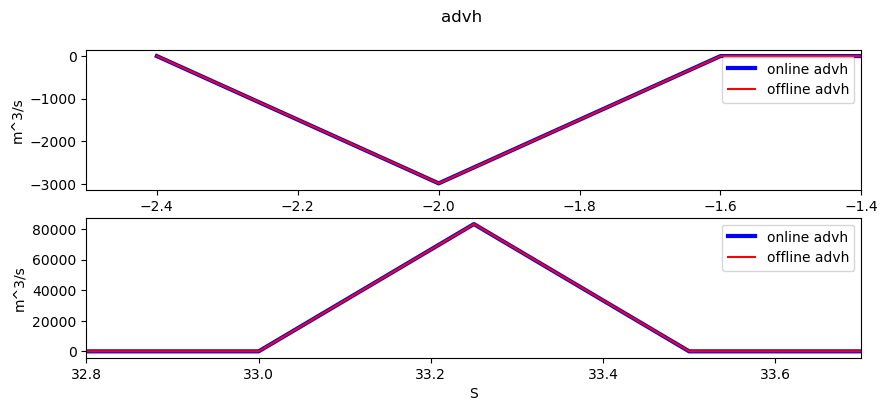

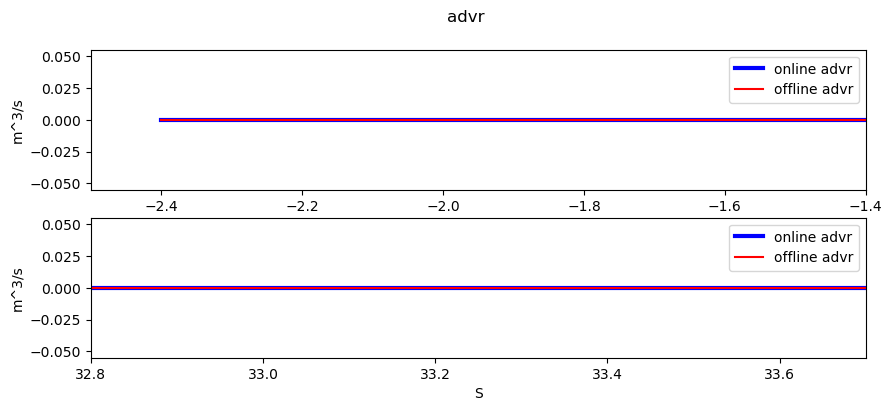

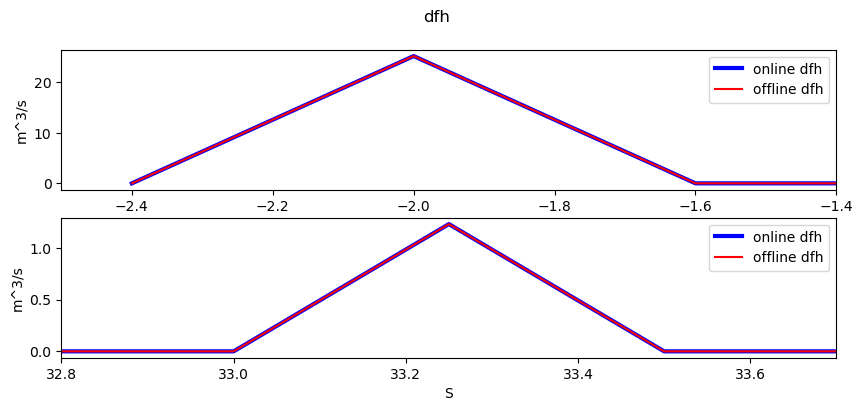

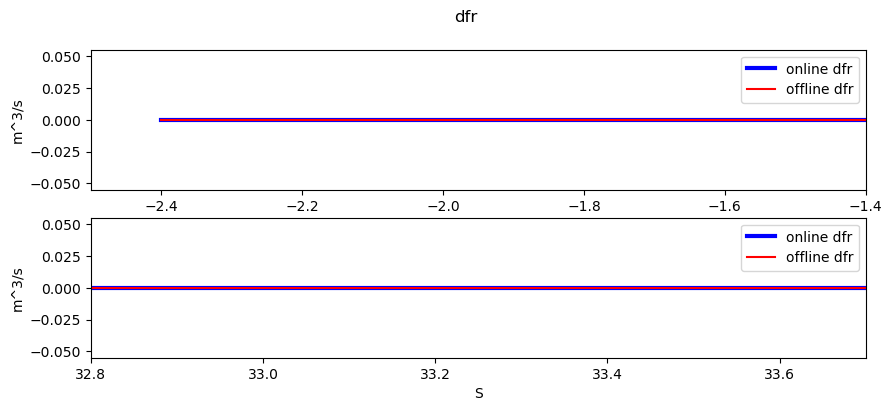

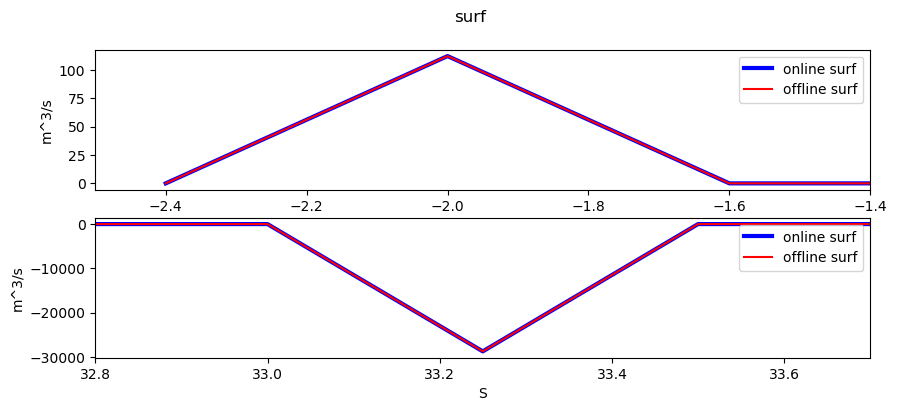

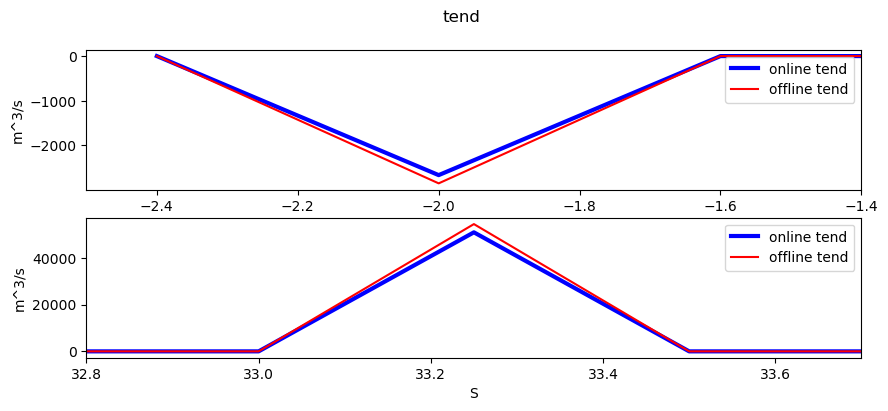

In [55]:
# plot these against the online terms

# make some kind of function to choose which term to use and make two plots


def plot_G(term,boundsS,boundsT,order):
    # just make term the index we want
    keyGT = list(G_T["BarentsS"][ts].keys())[term]
    keyGS = list(G_S["BarentsS"][ts].keys())[term]

    if term ==5:
        termoff = 6
    else:
        termoff = term

    fig = plt.figure()

    ax = plt.subplot(211)
    ax.plot(boundsT.flatten()[1:-1],G_T["BarentsS"][ts][keyGT],c="blue",linewidth=3,label="online " + order[term])
    ax.plot(boundsT.flatten()[1:-1],dF_Tnew[termoff]/binwidthT1,c="red",label="offline " + order[term])
    ax.set_ylabel("m^3/s")
    ax.set_xlabel("T")
    ax.legend(loc="best")
    ax.set_xlim(-2.5,-1.4)

    ax = plt.subplot(212)
    ax.plot(boundsS.flatten()[1:-1],G_S["BarentsS"][ts][keyGS],c="blue",linewidth=3,label="online " + order[term])
    ax.plot(boundsS.flatten()[1:-1],dF_Snew[termoff]/binwidthS1,c="red",label="offline " + order[term])
    ax.set_ylabel("m^3/s")
    ax.set_xlabel("S")
    ax.legend(loc="best")
    ax.set_xlim(32.8,33.7)

    plt.suptitle(order[term])


for i in range(6):
    plot_G(i,boundsS,boundsT,np.array(['advh', 'advr', 'dfh', 'dfr', 'surf', 'tend']))